# LangGraph SQL Agent + Routing — Walmart Sales
**Goal:** Add a routing preprocessor that formats the user question and decides whether to return a table or a text summary (conditional edges)

## Libraries

In [1]:
from langchain_openai import ChatOpenAI

# New: Prompt Engineering and Structured Output
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser

from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

# LangGraph
from langgraph.graph import END, StateGraph
from typing import TypedDict

import pandas as pd
import sqlalchemy as sql
import os
import re
import yaml
from pprint import pprint

C:\Users\User\AppData\Local\Temp\ipykernel_24028\3611898440.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini")

## 1.0 SQL Database Setup

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

db = SQLDatabase.from_uri(PATH_DB)

print("Tables:", db.get_usable_table_names())

Tables: ['daily_demand']


## 2.0 SQL Parsing Utility

In [4]:
def extract_sql_code(text: str):
    """Extract the SQL query from an LLM response. Returns None if not found."""
    if not text:
        return None
    for pat in [
        r"SQLQuery:\s*```sql\s*([\s\S]+?)```",
        r"```sql\s*([\s\S]+?)```",
        r"```[\w]*\s*(SELECT[\s\S]+?)```",
        r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)",
        r"(SELECT[\s\S]+?)(?:;|\n\n|$)",
    ]:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return m.group(1).strip().rstrip(";")
    return None

## 3.0 Routing Preprocessor Agent (AKA The Bouncer)
Used to format the user's question for the SQL generator and decide how the output is returned (table or text summary)

In [5]:
routing_preprocessor_prompt = PromptTemplate(
    template="""
    You are an expert in routing decisions for a SQL database agent. Your job is to:

    1. Determine what the correct format for a User's Question should be for use with a SQL translator agent.
    2. Determine whether the results should be returned as a data table or as a short text summary, based on the user's question.

    Use the following criteria to route the initial user question:

    From the incoming user question, remove any details about the format of the final response (table or summary) and return only the part of the question that is relevant for the SQL generator agent. This will be the 'formatted_user_question_sql_only'. If 'None' is found, return the original user question.

    Next, determine if the user would like a data 'table' or a natural-language 'summary' returned with the results of the SQL query. Select 'summary' whenever the user asks to summarize, describe, interpret, or explain the results in words, sentences, or prose. If unknown, not specified or 'None' is found, then select 'table'. This will be the 'routing_preprocessor_decision'.

    Return JSON with 'formatted_user_question_sql_only' and 'routing_preprocessor_decision'.

    INITIAL_USER_QUESTION: {initial_question}
    """,
    input_variables=["initial_question"]
)

routing_preprocessor = routing_preprocessor_prompt | llm | JsonOutputParser()

routing_preprocessor

PromptTemplate(input_variables=['initial_question'], input_types={}, partial_variables={}, template="\n    You are an expert in routing decisions for a SQL database agent. Your job is to:\n\n    1. Determine what the correct format for a User's Question should be for use with a SQL translator agent.\n    2. Determine whether the results should be returned as a data table or as a short text summary, based on the user's question.\n\n    Use the following criteria to route the initial user question:\n\n    From the incoming user question, remove any details about the format of the final response (table or summary) and return only the part of the question that is relevant for the SQL generator agent. This will be the 'formatted_user_question_sql_only'. If 'None' is found, return the original user question.\n\n    Next, determine if the user would like a data 'table' or a natural-language 'summary' returned with the results of the SQL query. Select 'summary' whenever the user asks to summar

In [6]:
QUESTION = "What are the top 10 items by total cumulative demand value?"

response = routing_preprocessor.invoke({"initial_question": QUESTION})
pprint(response)

{'formatted_user_question_sql_only': 'What are the top 10 items by total '
                                     'cumulative demand value?',
 'routing_preprocessor_decision': 'table'}


In [7]:
QUESTION = "What is the total demand value by year? Summarize the trend in words."

response = routing_preprocessor.invoke({"initial_question": QUESTION})
pprint(response)

{'formatted_user_question_sql_only': 'What is the total demand value by year?',
 'routing_preprocessor_decision': 'summary'}


In [8]:
QUESTION = "What is the total demand value by year-month? Please return a table."

response = routing_preprocessor.invoke({"initial_question": QUESTION})
pprint(response)

{'formatted_user_question_sql_only': 'What is the total demand value by '
                                     'year-month?',
 'routing_preprocessor_decision': 'table'}


## 4.0 SQL Agent

In [9]:
sql_generator = create_sql_query_chain(
    llm=llm,
    db=db,
    k=int(1e7),  # Set high to avoid LIMIT truncation
)

sql_generator

RunnableAssign(mapper={
  input: RunnableLambda(...),
  table_info: RunnableLambda(...)
})
| RunnableLambda(lambda x: {k: v for k, v in x.items() if k not in ('question', 'table_names_to_use')})
| PromptTemplate(input_variables=['input', 'table_info'], input_types={}, partial_variables={'top_k': '10000000'}, template='You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.\nUnless the user specifies in the question a specific number of examples to obtain, query for at most {top_k} results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.\nNever query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.\nPay attention to use only the column names you can see

## 5.0 Summarizer Agent
Used when the router decides the user wants a text summary instead of a table

In [10]:
summarizer_prompt = PromptTemplate(
    template="""
    You are a business analyst. Using the SQL query results below, answer the user's question in a few concise sentences. Report concrete numbers where relevant.

    USER_QUESTION: {question}

    DATA (records): {data}
    """,
    input_variables=["question", "data"]
)

summarizer = summarizer_prompt | llm | StrOutputParser()

## 6.0 LangGraph Workflow with Conditional Edges

In [11]:
class GraphState(TypedDict):
    """Represents the state of our graph."""
    user_question: str
    formatted_user_question_sql_only: str
    routing_preprocessor_decision: str
    sql_query: str
    data: dict
    summary: str

In [12]:
# New: determines the path + formats the question
def preprocess_routing(state):
    print("---ROUTER---")
    question = state.get("user_question")
    response = routing_preprocessor.invoke({"initial_question": question})
    return {
        "formatted_user_question_sql_only": response.get('formatted_user_question_sql_only'),
        "routing_preprocessor_decision": response.get('routing_preprocessor_decision'),
    }

In [13]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("formatted_user_question_sql_only")
    # Handle case when formatted_user_question_sql_only is None
    if question is None:
        question = state.get("user_question")
    sql_query = sql_generator.invoke({"question": question})
    sql_query = extract_sql_code(sql_query)
    return {"sql_query": sql_query}

In [14]:
def convert_dataframe(state):
    print("---CONVERT DATA FRAME---")
    sql_query = state.get("sql_query")
    df = pd.read_sql(sql_query, conn)
    return {"data": df.to_dict(orient="records")}

In [15]:
# New: decision logic for the conditional edge
def decide_table_or_summary(state):
    print("---DECIDE TABLE OR SUMMARY---")
    return "summary" if state.get('routing_preprocessor_decision') == "summary" else "table"

In [16]:
# New: text summary node
def generate_summary(state):
    print("---GENERATE SUMMARY---")
    summary = summarizer.invoke({
        "question": state.get("user_question"),
        "data": state.get("data"),
    })
    return {"summary": summary}

In [17]:
def state_printer(state):
    """Print the state."""
    print("---STATE PRINTER---")
    print(f"User Question: {state.get('user_question')}")
    print(f"Formatted Question (SQL): {state.get('formatted_user_question_sql_only')}")
    pprint(f"SQL Query: \n{state.get('sql_query')}\n")
    print(f"Table or Summary: {state.get('routing_preprocessor_decision')}")
    if state.get('summary'):
        print(f"Summary: \n{state.get('summary')}\n")
    print(f"Data: \n{pd.DataFrame(state.get('data'))}\n")

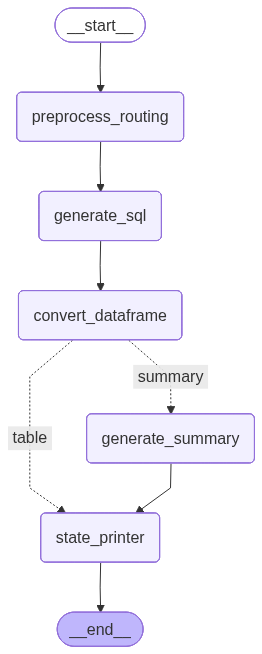

In [18]:
workflow = StateGraph(GraphState)

# Nodes
workflow.add_node("preprocess_routing", preprocess_routing)
workflow.add_node("generate_sql", generate_sql)
workflow.add_node("convert_dataframe", convert_dataframe)
workflow.add_node("generate_summary", generate_summary)
workflow.add_node("state_printer", state_printer)

# Edges
workflow.set_entry_point("preprocess_routing")
workflow.add_edge("preprocess_routing", "generate_sql")
workflow.add_edge("generate_sql", "convert_dataframe")

# New: conditional edges
workflow.add_conditional_edges(
    "convert_dataframe",
    decide_table_or_summary,
    {
        # Result : Step Name To Go To
        "summary": "generate_summary",
        "table": "state_printer",
    }
)

workflow.add_edge("generate_summary", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()
app

## 7.0 Testing the Graph

In [19]:
QUESTION = "What are the top 10 items by total cumulative demand value?"

response = app.invoke({"user_question": QUESTION})
print("Decision:", response.get('routing_preprocessor_decision'))
pd.DataFrame(response.get('data'))

---ROUTER---


---GENERATE SQL---


---CONVERT DATA FRAME---
---DECIDE TABLE OR SUMMARY---
---STATE PRINTER---
User Question: What are the top 10 items by total cumulative demand value?
Formatted Question (SQL): What are the top 10 items by total cumulative demand value?
('SQL Query: \n'
 'SELECT "item_id", SUM("value") AS total_demand FROM daily_demand GROUP BY '
 '"item_id" ORDER BY total_demand DESC LIMIT 10\n')
Table or Summary: table
Data: 
       item_id  total_demand
0  FOODS_3_090       1002529
1  FOODS_3_586        920242
2  FOODS_3_252        565299
3  FOODS_3_555        491287
4  FOODS_3_714        396172
5  FOODS_3_587        396119
6  FOODS_3_694        390001
7  FOODS_3_226        363082
8  FOODS_3_202        295689
9  FOODS_3_723        284333

Decision: table


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


In [20]:
QUESTION = "What is the total demand value by year? Summarize the trend in words."

response = app.invoke({"user_question": QUESTION})
print("Decision:", response.get('routing_preprocessor_decision'))
print(response.get('summary'))

---ROUTER---


---GENERATE SQL---


---CONVERT DATA FRAME---
---DECIDE TABLE OR SUMMARY---
---GENERATE SUMMARY---


---STATE PRINTER---
User Question: What is the total demand value by year? Summarize the trend in words.
Formatted Question (SQL): What is the total demand value by year?
('SQL Query: \n'
 'SELECT strftime(\'%Y\', "date") AS "year", SUM("value") AS "total_demand"\n'
 'FROM daily_demand\n'
 'GROUP BY "year"\n'
 'ORDER BY "year"\n')
Table or Summary: summary
Summary: 
The total demand value by year is as follows:
- 2011: 924,780
- 2012: 1,237,760
- 2013: 1,128,577
- 2014: 1,012,332
- 2015: 1,035,293
- 2016: 331,249

The trend shows a significant increase in demand from 2011 to 2012, peaking in 2012 with over 1.2 million. However, there is a gradual decline in demand from 2013 to 2015, with a notable drop in 2016 to just 331,249, indicating a substantial decrease that may require further investigation.

Data: 
   year  total_demand
0  2011        924780
1  2012       1237760
2  2013       1128577
3  2014       1012332
4  2015       1035293
5  2016        331249

Decision: summary
The tota

In [21]:
QUESTION = "What is the total demand value by year-month? Please return a table."

response = app.invoke({"user_question": QUESTION})
print("Decision:", response.get('routing_preprocessor_decision'))
pd.DataFrame(response.get('data'))

---ROUTER---


---GENERATE SQL---


---CONVERT DATA FRAME---
---DECIDE TABLE OR SUMMARY---
---STATE PRINTER---
User Question: What is the total demand value by year-month? Please return a table.
Formatted Question (SQL): What is the total demand value by year-month?
('SQL Query: \n'
 'SELECT strftime(\'%Y-%m\', "date") AS "year_month", SUM("value") AS '
 '"total_demand" FROM daily_demand GROUP BY "year_month" ORDER BY "year_month" '
 'LIMIT 10000000\n')
Table or Summary: table
Data: 
   year_month  total_demand
0     2011-01          9758
1     2011-02         69217
2     2011-03         64767
3     2011-04         69084
4     2011-05         69958
..        ...           ...
59    2015-12         70503
60    2016-01         80705
61    2016-02         88471
62    2016-03         89161
63    2016-04         72912

[64 rows x 2 columns]

Decision: table


,year_month,total_demand
0,2011-01,9758
1,2011-02,69217
2,2011-03,64767
3,2011-04,69084
4,2011-05,69958
...,...,...
59,2015-12,70503
60,2016-01,80705
61,2016-02,88471
62,2016-03,89161


In [22]:
conn.close()